<a href="https://colab.research.google.com/github/RainMustFall/pancreas-segmentation/blob/main/Pancreas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentacja trzustki za pomocą klasteryzacji wektorów cech

Eksperymenty przeprowadzono przy użyciu procesora graficznego Nvidia A100 w Google Colab.

Aby uruchomić, należy dodać dwa [sekrety](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb#scrollTo=dEoigYI9Jw_K): token Hugging Face (można stworzyć [tutaj](https://huggingface.co/settings/tokens)) do pobierania modelu (`huggingface_token`) oraz ścieżkę do folderu z obrazami (`data_folder`), na przykład `/content/drive/MyDrive/pancreas_data`.

In [26]:
import gc
import os

import torch
import timm
import tifffile
import huggingface_hub
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from collections import namedtuple
from collections.abc import Iterator
from tqdm.notebook import tqdm
from torchvision import transforms
from PIL import Image

from google.colab import userdata

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

Pobieramy model i zapisujemy go na GPU

In [27]:
huggingface_hub.login(token=userdata.get('huggingface_token'))

model = timm.create_model(
    "hf-hub:bioptimus/H-optimus-0", pretrained=True, init_values=1e-5, dynamic_img_size=False
)
model.to("cuda")
model = model.eval()

Odczytujemy jeden obraz

Image shape: (7687, 11220, 3)


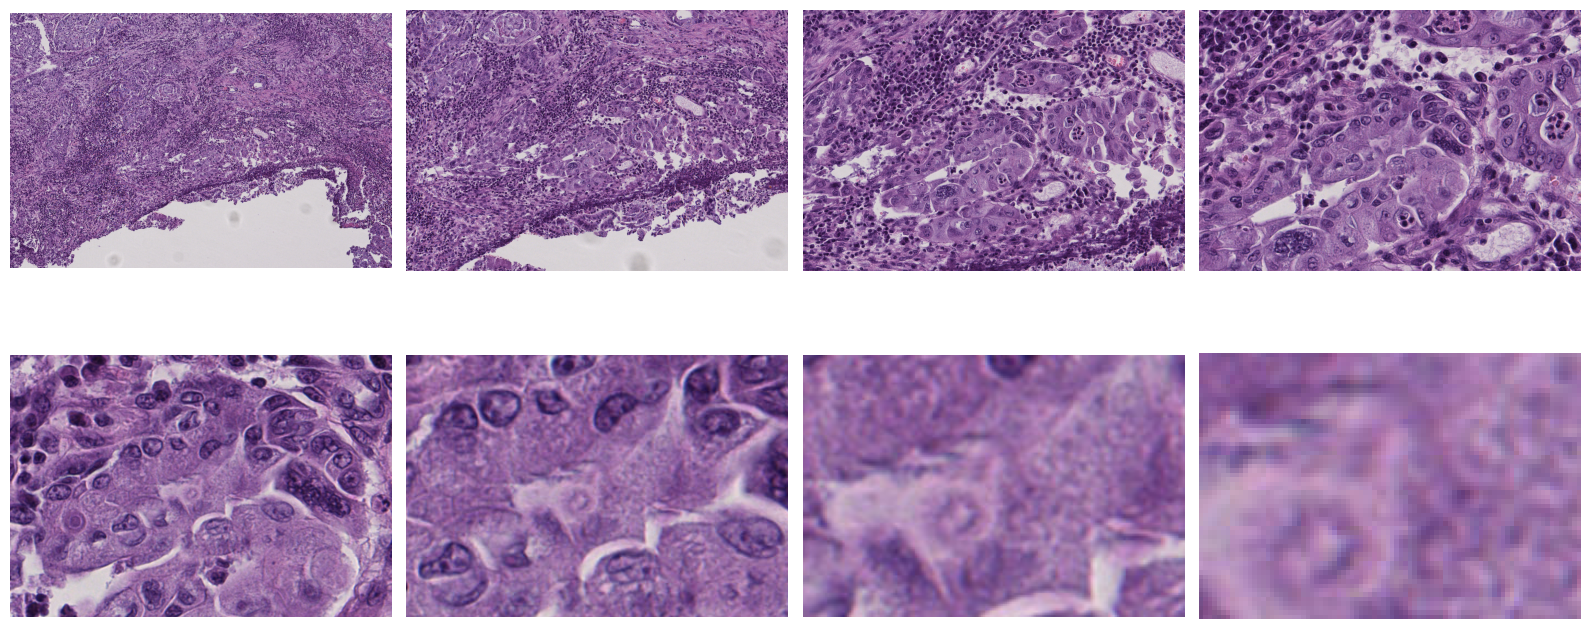

In [28]:
def show_image(img, **kwargs):
    """Plot large image at different resolutions."""
    fig, ax = plt.subplots(2,4, figsize=(16,8))
    mid = [s//2 + 600 for s in img.shape[:2]]
    for a,t,u in zip(ax.ravel(),[1,2,4,8,16,32,64,128],[16,8,4,2,1,1,1,1]):
        sl = tuple(slice(c - s//t//2, c + s//t//2, u) for s,c in zip(img.shape[:2],mid))
        a.imshow(img[sl], **kwargs)
        a.axis('off')
    plt.tight_layout()
    plt.show()

DATA_FOLDER = userdata.get('data_folder')

IMG_PATH = os.path.join(DATA_FOLDER, 'H24 11842-B-15-1 (1, x=30706, y=56412, w=11220, h=7687).tif')
img = tifffile.imread(IMG_PATH)

print(f"Image shape: {img.shape}")
show_image(img)

Opiszemy funkcję, która będzie generować współrzędne kwadratów o wymiarach $224 \times 224$ piksele z krokiem 32. Współrzędne te zostaną użyte do pocięcia oryginalnego obrazu i podania fragmentów na wejście sieci neuronowej. Nieco później zostaną one również wykorzystane do prawidłowego dopasowania wyników segmentacji do oryginalnych obszarów obrazu.

In [29]:
Patch = namedtuple('Patch', ['start_y', 'end_y', 'start_x', 'end_x'])

def generate_patches(
    image_shape: tuple[int, int, int],
) -> Iterator[Patch]:
    img_height, img_width, _ = image_shape
    num_vertical_crops = (img_height - CROP_SIZE) // STEP_SIZE + 1
    num_horizontal_crops = (img_width - CROP_SIZE) // STEP_SIZE + 1

    for i in range(num_vertical_crops):
        for j in range(num_horizontal_crops):
            start_y = i * STEP_SIZE
            end_y = start_y + CROP_SIZE
            start_x = j * STEP_SIZE
            end_x = start_x + CROP_SIZE
            yield Patch(start_y, end_y, start_x, end_x)

Ekstrakcja cech odbywa się w funkcji `extract_features`. Z obrazu wycinane są obszary o wymiarach $224 \times 224$ piksele (model działa tylko z takim rozmiarem), które są gromadzone w partiach po 256 fragmentów i podawane na wejście sieci. Rozmiar partii można regulować.

In [30]:
INFERENCE_BATCH_SIZE = 256
CROP_SIZE = 224
STEP_SIZE = 32


def run_inference_for_batch(cropped_images: list[Image.Image]) -> np.array:
    batched_crops = torch.stack(cropped_images)
    batched_crops.requires_grad = False
    batched_crops = batched_crops.to("cuda")
    features = model(batched_crops)
    return features.cpu().numpy()


def extract_features(img: np.array, model: torch.nn.Module) -> np.array:
    """Crop the image into tiles and extract features from each tile.

    Args:
        img (np.array): Image to extract features from.
          (height x width x channels) shape, uint8 dtype.
        model (torch.nn.Module): Model to use for feature extraction.

    Returns:
        np.array: Extracted features of the shape (num_crops, num_features).
    """

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.707223, 0.578729, 0.703617),
            std=(0.211883, 0.230117, 0.177517)
        ),
    ])

    cropped_images = []
    features = []
    with (
        torch.autocast(device_type="cuda", dtype=torch.float16),
        torch.inference_mode()
    ):
        for start_y, end_y, start_x, end_x in tqdm(list(
            generate_patches(image_shape=img.shape)
        )):
            patch = img[start_y:end_y, start_x:end_x]
            pil_patch = Image.fromarray(patch)

            transformed_patch = transform(pil_patch)
            cropped_images.append(transformed_patch)

            if len(cropped_images) == INFERENCE_BATCH_SIZE:
                features.append(run_inference_for_batch(cropped_images))
                cropped_images = []
                gc.collect()

        features.append(run_inference_for_batch(cropped_images))

    return np.concatenate(features)

In [31]:
features = extract_features(img, model)

  0%|          | 0/80496 [00:00<?, ?it/s]

Po otrzymaniu wektorów cech, klasteryzujemy je metodą k-średnich

In [37]:
NUM_CLUSTERS = 3

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(features)

print(f"Shape of cluster_labels: {cluster_labels.shape}")
print(f"Unique cluster labels: {set(cluster_labels)}")

Shape of cluster_labels: (80496,)
Unique cluster labels: {np.int32(0), np.int32(1), np.int32(2)}


Teraz wizualizujemy wyniki.

Ponieważ oryginalne fragmenty nakładały się na siebie, każdy punkt pokolorujemy na uśredniony kolor proporcjonalnie do tego, jak sklasyfikowano wszystkie fragmenty, które na niego nałożyły się. Zbudujmy trójwymiarową tabelę (wysokość obrazu / 32) x (szerokość obrazu / 32) x (liczba klastrów). Element $i,j,k$ oznacza liczbę fragmentów zawierających obszar $32 \times 32$ o współrzędnych $i,j$, sklasyfikowanych jako klaster $k$.

In [38]:
def build_cluster_count_grid(
    img_shape: tuple[int, int, int],
    cluster_labels: np.array,
) -> np.array:
    img_height, img_width, _ = img_shape

    blended_grid_height = img_height // STEP_SIZE
    blended_grid_width = img_width // STEP_SIZE

    cluster_count_grid = np.zeros((
        blended_grid_height,
        blended_grid_width,
        NUM_CLUSTERS
    ), dtype=int)

    generated_patches_list = list(generate_patches(image_shape=img_shape))
    print(f"Number of generated patches: {len(generated_patches_list)}")
    print(f"Length of cluster_labels: {len(cluster_labels)}")

    for patch_idx, patch in enumerate(
        generated_patches_list
    ):
        current_cluster = cluster_labels[patch_idx]

        blended_y_min = patch.start_y // STEP_SIZE
        blended_y_max = (patch.end_y - 1) // STEP_SIZE

        blended_x_min = patch.start_x // STEP_SIZE
        blended_x_max = (patch.end_x - 1) // STEP_SIZE

        for by in range(blended_y_min, blended_y_max + 1):
            for bx in range(blended_x_min, blended_x_max + 1):
                cluster_count_grid[by, bx, current_cluster] += 1

    return cluster_count_grid

Przekształćmy trójwymiarową tabelę w mapę kolorów, uśredniając kolory

In [44]:
def build_color_grid(
    img_shape: tuple[int, int, int],
    cluster_labels: np.array
) -> np.array:
    cluster_count_grid = build_cluster_count_grid(img_shape, cluster_labels)
    count_grid_height, count_grid_width, num_clusters = cluster_count_grid.shape

    # Create a blank image to draw the new aggregated clustered regions
    color_grid_image = np.zeros(img_shape, dtype=np.uint8)

    colormap = mcolors.ListedColormap(
        ['red', 'blue', 'green', 'purple', 'orange', 'yellow', 'white', 'grey']
    )
    colors = np.array([colormap(i) for i in range(num_clusters)])

    for by in range(count_grid_height):
        for bx in range(count_grid_width):
            total_votes = np.sum(cluster_count_grid[by, bx])

            # Mixing the colors according to number of votes for each class
            color_rgba = np.dot(
                cluster_count_grid[by, bx],
                colors
            ) / total_votes

            # Filling in the right (STEP_SIZE x STEP_SIZE) square
            color_rgb = (np.array(color_rgba[:3]) * 255).astype(np.uint8)
            color_grid_image[
                by * STEP_SIZE:(by + 1) * STEP_SIZE,
                bx * STEP_SIZE:(bx + 1) * STEP_SIZE
            ] = color_rgb

    return color_grid_image

Number of generated patches: 80496
Length of cluster_labels: 80496


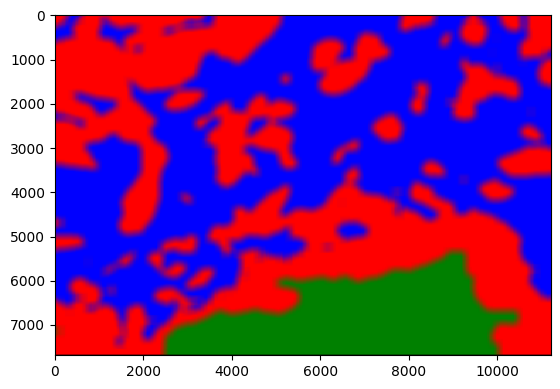

In [45]:
plt.imshow(build_color_grid(img.shape, cluster_labels))

Nałóżmy otrzymaną mapę na oryginalny obraz'

Number of generated patches: 80496
Length of cluster_labels: 80496


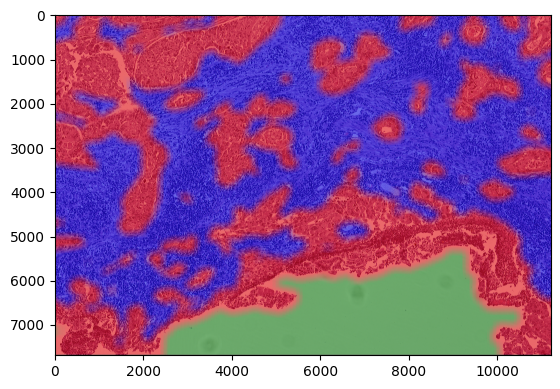

In [46]:
alpha = 0.5

blended_image_agg = (
    img * (1 - alpha) +
    build_color_grid(img.shape, cluster_labels) * alpha
).astype(np.uint8)

plt.imshow(blended_image_agg)